In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb

In [13]:
df = pd.read_csv('../preprocessing/credit_risk_encoded.csv')

X = df.drop(columns=['customer_id', 'loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Train:', X_train_smote.shape, '| Test:', X_test.shape)

Train: (40746, 26) | Test: (6515, 26)


In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

In [15]:
results = []

for name, clf in models.items():
    print(f'Training {name}...')
    clf.fit(X_train_smote, y_train_smote)
    
    preds_proba = clf.predict_proba(X_test)[:, 1]
    preds_class = clf.predict(X_test)
    
    auc = roc_auc_score(y_test, preds_proba)
    report = classification_report(y_test, preds_class, output_dict=True)
    
    results.append({
        'Model': name,
        'AUC': auc,
        'Precision (1)': report['1']['precision'],
        'Recall (1)': report['1']['recall'],
        'F1 (1)': report['1']['f1-score'],
        'Accuracy': report['accuracy']
    })

print('All models have been done')

Training Logistic Regression...


d:\banque misr\Credit_Risk_Score\Customer-risk-score\credit_risk_proj\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...
Training LightGBM...
Training KNN...
Training Naive Bayes...
All models have been done


In [16]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='AUC', ascending=False).reset_index(drop=True)
results_df

,Model,AUC,Precision (1),Recall (1),F1 (1),Accuracy
0,LightGBM,0.945037,0.969668,0.719916,0.826333,0.933998
1,XGBoost,0.944713,0.962963,0.731879,0.831667,0.935380
2,Random Forest,0.925472,0.958095,0.707952,0.814245,0.929547
3,Gradient Boosting,0.916345,0.902569,0.717101,0.799216,0.921412
4,Logistic Regression,0.842211,0.671375,0.501759,0.574305,0.837759
5,Decision Tree,0.841300,0.730899,0.760732,0.745517,0.886723
6,KNN,0.801409,0.495699,0.648839,0.562024,0.779432
7,Naive Bayes,0.774485,0.363330,0.758621,0.491340,0.657406


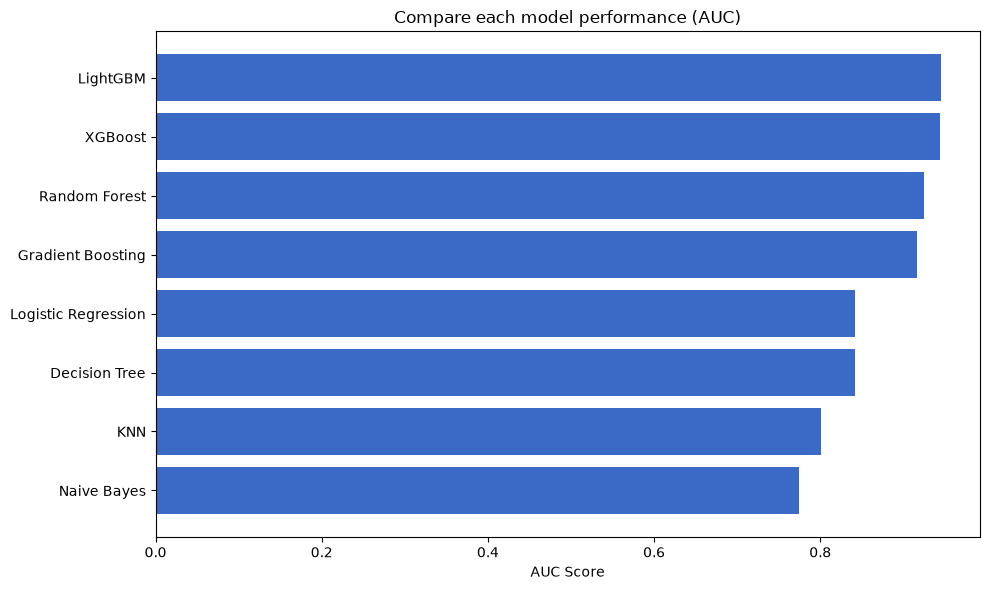

In [17]:
plt.figure(figsize=(10, 6))
plt.barh(results_df['Model'], results_df['AUC'], color='#3a6ac6')
plt.xlabel('AUC Score')
plt.title('Compare each model performance (AUC)')
plt.gca().invert_yaxis()  # الأعلى AUC يبان فوق
plt.tight_layout()
plt.savefig('model_comparison_auc.png')
plt.show()

In [18]:
overfit_results = []

for name, clf in models.items():
    train_proba = clf.predict_proba(X_train)[:, 1]
    test_proba = clf.predict_proba(X_test)[:, 1]
    
    train_auc = roc_auc_score(y_train, train_proba)
    test_auc = roc_auc_score(y_test, test_proba)
    
    overfit_results.append({
        'Model': name,
        'Train AUC': train_auc,
        'Test AUC': test_auc,
        'Gap': train_auc - test_auc
    })

overfit_df = pd.DataFrame(overfit_results)
overfit_df = overfit_df.sort_values(by='Gap', ascending=False).reset_index(drop=True)
overfit_df

,Model,Train AUC,Test AUC,Gap
0,Decision Tree,1.000000,0.841300,0.158700
1,KNN,0.950275,0.801409,0.148867
2,Random Forest,1.000000,0.925472,0.074528
3,XGBoost,0.989407,0.944713,0.044693
4,LightGBM,0.971888,0.945037,0.026851
5,Gradient Boosting,0.926910,0.916345,0.010565
6,Logistic Regression,0.849171,0.842211,0.006960
7,Naive Bayes,0.778801,0.774485,0.004315


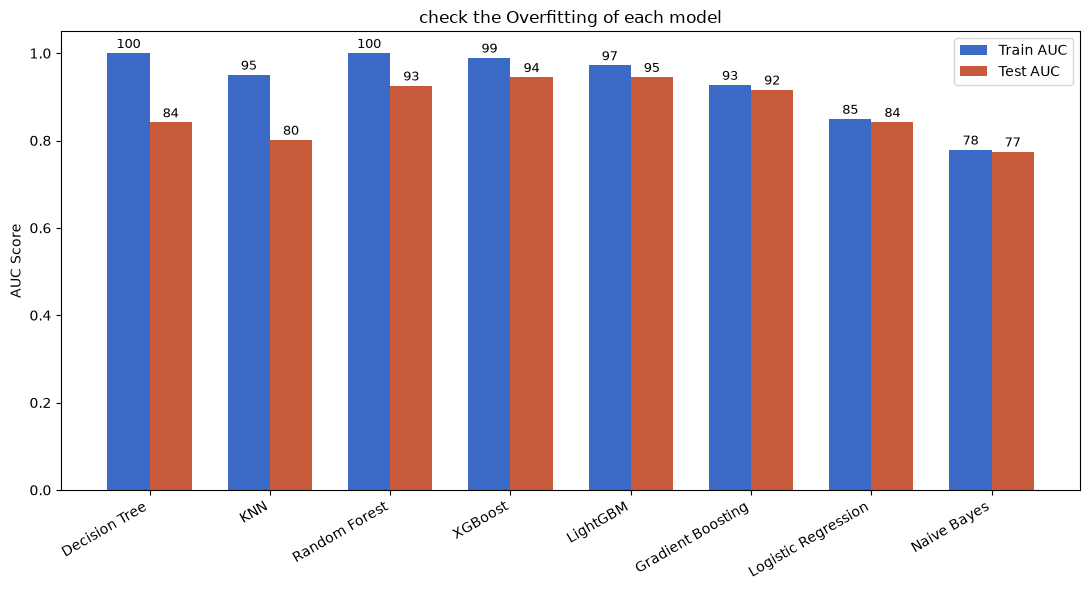

In [19]:
x = np.arange(len(overfit_df))
width = 0.35

plt.figure(figsize=(11, 6))
bars1 = plt.bar(x - width/2, overfit_df['Train AUC'], width, label='Train AUC', color='#3a6ac6')
bars2 = plt.bar(x + width/2, overfit_df['Test AUC'], width, label='Test AUC', color='#c65a3a')

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
              f'{height*100:.0f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
              f'{height*100:.0f}', ha='center', va='bottom', fontsize=9)

plt.xticks(x, overfit_df['Model'], rotation=30, ha='right')
plt.ylabel('AUC Score')
plt.title('check the Overfitting of each model')
plt.legend()
plt.tight_layout()
plt.savefig('overfitting_comparison.png')
plt.show()